# Course 5, Module 2, Lesson 2 Screencasts

## M2L2SC1: Transform, Reduce, Select: Advanced Feature Engineering

### Step 1: Transforming Features to Enhance Patterns

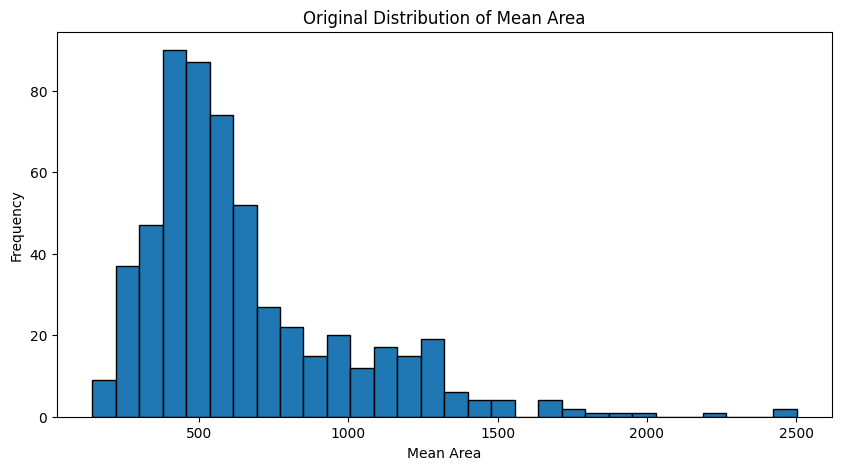

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load the dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the original distribution of a skewed feature
plt.figure(figsize=(10, 5))
plt.hist(df['mean area'], bins=30, edgecolor='black')
plt.title('Original Distribution of Mean Area')
plt.xlabel('Mean Area')
plt.ylabel('Frequency')
plt.show()


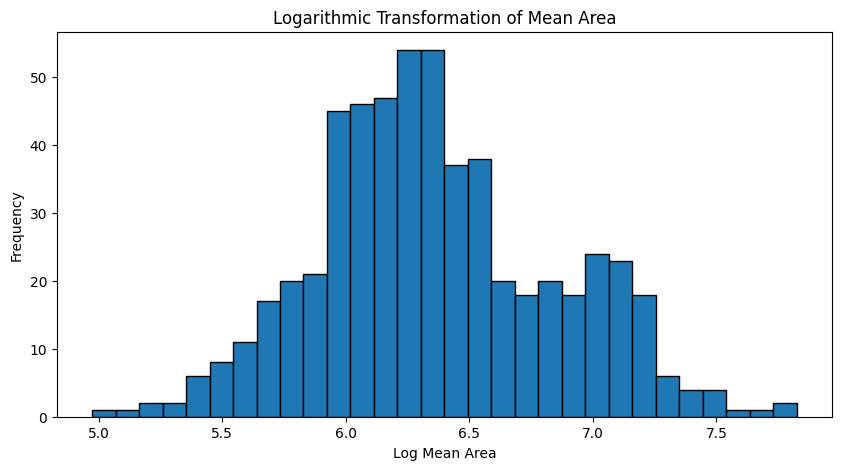

In [ ]:
# Apply a logarithmic transformation
df['log_mean_area'] = np.log(df['mean area'] + 1)

# Display the transformed distribution
plt.figure(figsize=(10, 5))
plt.hist(df['log_mean_area'], bins=30, edgecolor='black')
plt.title('Logarithmic Transformation of Mean Area')
plt.xlabel('Log Mean Area')
plt.ylabel('Frequency')
plt.show()

### Step 2: Dimensionality Reduction

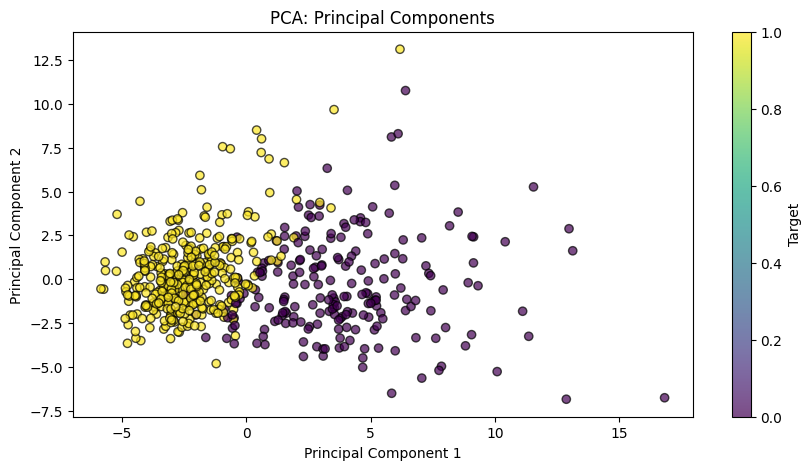

In [ ]:
# Standardize features
from sklearn.preprocessing import StandardScaler

features = df.drop(['target'], axis=1)
scaled_features = StandardScaler().fit_transform(features)

# Apply PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Create a DataFrame with the principal components
principal_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])

# Plot the principal components
plt.figure(figsize=(10, 5))
plt.scatter(principal_df['Principal Component 1'], principal_df['Principal Component 2'], c=df['target'], edgecolor='black', alpha=0.7)
plt.title('PCA: Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Target')
plt.show()

### Step 3: Selecting Features


In [ ]:
# Specify target variable
target = 'target'

# Apply Recursive Feature Elimination (RFE)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)  # Increase max_iter for convergence
rfe = RFE(estimator=model, n_features_to_select=5)  # Select top 5 features
fit = rfe.fit(features, df[target])

# Display selected features
selected_features = list(features.columns[fit.support_])
print("Selected Features:", selected_features)

Selected Features: ['mean radius', 'texture error', 'worst radius', 'worst compactness', 'worst concavity']


### Step 4: Build a Model

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[selected_features], df[target], test_size=0.3, random_state=42)

# Build a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Print the model parameters
print(model)

RandomForestClassifier(random_state=42)


### Step 5: Evaluate the Model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.95
Confusion Matrix:
 [[ 58   5]
 [  3 105]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.94        63
           1       0.95      0.97      0.96       108

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



### Step 6: Compare the Results

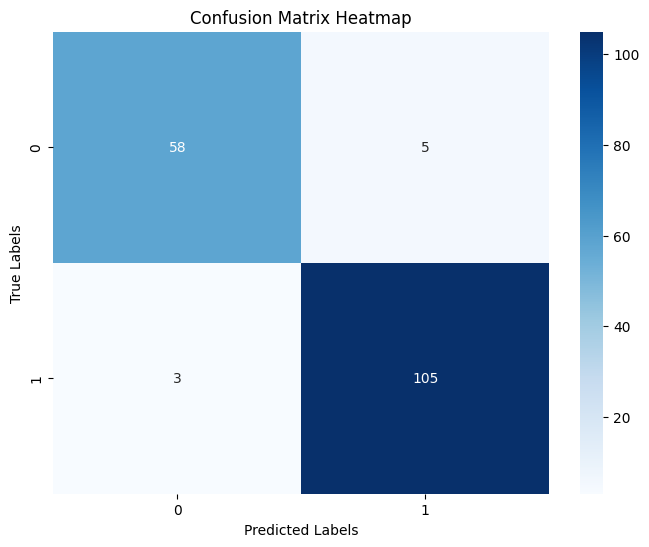

Random Forest Model Accuracy: 0.95
Baseline (Logistic Regression) Model Accuracy: 0.98


In [ ]:
# Visualize the results using a confusion matrix heatmap
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Compare accuracy with baseline model (Logistic Regression)
baseline_model = LogisticRegression(max_iter=10000)
baseline_model.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline_model.predict(X_test))

print(f"Random Forest Model Accuracy: {accuracy:.2f}")
print(f"Baseline (Logistic Regression) Model Accuracy: {baseline_accuracy:.2f}")